# Analise de Regimes de Mercado via HMM Gaussiano

**Sprint 2 -- Quant Trading System**

Este notebook implementa o pipeline completo de deteccao de regime:
1. Carregamento dos dados OHLCV (WDO e WIN)
2. Calculo das 5 features de regime
3. Validacao de estacionariedade (ADF + KPSS)
4. Seleccao de modelo HMM (K estados, tipo de covariancia)
5. Visualizacao dos regimes detectados
6. Exportacao dos resultados

In [1]:
%matplotlib inline

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns

# Ensure project root is in path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features.regime_features import RegimeFeatureEngineer, FEATURE_COLUMNS
from src.models.hmm_regime import HMMRegimeDetector

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Configuracao visual
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (16, 8),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

# Cores dos regimes
REGIME_COLORS = {
    'low_vol': '#2ecc71',
    'trending': '#f39c12',
    'high_vol': '#e74c3c',
}

print('Dependencias carregadas com sucesso.')

Dependencias carregadas com sucesso.


## 1. Carregamento dos Dados

In [2]:
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Descobrir ficheiros Parquet disponiveis
parquet_files = sorted(RAW_DIR.glob('*.parquet'))
print(f'Ficheiros encontrados: {len(parquet_files)}')
for f in parquet_files:
    print(f'  - {f.name}')

# Carregar dados
datasets = {}
for f in parquet_files:
    symbol = f.stem.split('_')[0]  # WDO or WIN
    df = pd.read_parquet(f)
    datasets[symbol] = df
    print(f'\n{symbol}: {len(df)} candles, periodo: {df.index.min()} a {df.index.max()}')
    print(df.head(3))

Ficheiros encontrados: 2
  - WDO_5m_20260505.parquet
  - WIN_5m_20260505.parquet

WDO: 7130 candles, periodo: 2026-02-11 01:50:00+00:00 a 2026-05-05 21:25:00+00:00
                             open    high     low   close  volume
datetime                                                         
2026-02-11 01:50:00+00:00  5.1967  5.1967  5.1967  5.1967       0
2026-02-11 02:10:00+00:00  5.1967  5.1967  5.1967  5.1967       0
2026-02-11 03:00:00+00:00  5.1967  5.1967  5.1967  5.1967       0

WIN: 5014 candles, periodo: 2026-02-04 13:00:00+00:00 a 2026-05-05 19:55:00+00:00
                                    open           high           low  \
datetime                                                                
2026-02-04 13:00:00+00:00  185670.984375  185670.984375  185515.15625   
2026-02-04 13:05:00+00:00  185417.281250  185417.281250  184346.31250   
2026-02-04 13:10:00+00:00  184327.000000  184384.187500  184154.81250   

                                   close  volume  
dateti

## 2. Calculo de Features

In [3]:
engineer = RegimeFeatureEngineer(
    vol_window=20,
    mom_window=10,
    vol_rel_window=60,
    zscore_window=60,
    clip_range=5.0,
    epsilon=1e-10,
)

features_dict = {}
for symbol, df in datasets.items():
    print(f'\n--- {symbol} ---')
    features = engineer.compute_all_features(df)
    features_dict[symbol] = features
    print(f'Features calculadas: {len(features)} rows validos (de {len(df)} originais)')
    print(f'Colunas: {list(features.columns)}')
    print(features.describe().round(4))

2026-05-05 19:30:47.757 | DEBUG    | src.features.regime_features:__init__:101 - RegimeFeatureEngineer initialized: vol_window=20, mom_window=10, vol_rel_window=60, zscore_window=60, clip_range=5.0, epsilon=1e-10, warmup_period=60


2026-05-05 19:30:47.757 | INFO     | src.features.regime_features:compute_all_features:290 - Computing regime features for 7130 rows


2026-05-05 19:30:47.761 | WARNING  | src.features.regime_features:compute_log_relative_volume:207 - Volume is all zeros -- likely a proxy ticker without volume data. Setting log_rel_volume to 0.0 (neutral).


2026-05-05 19:30:47.768 | DEBUG    | src.features.regime_features:compute_all_features:318 - Removed 61 session-start candles (overnight gaps)


2026-05-05 19:30:47.769 | DEBUG    | src.features.regime_features:compute_all_features:326 - Removed warm-up period (60 rows)


...

2026-05-05 19:30:47.788 | DEBUG    | src.features.regime_features:compute_all_features:318 - Removed 60 session-start candles (overnight gaps)


2026-05-05 19:30:47.789 | DEBUG    | src.features.regime_features:compute_all_features:326 - Removed warm-up period (60 rows)


2026-05-05 19:30:47.791 | DEBUG    | src.features.regime_features:compute_all_features:335 - Dropped 8 rows with NaN after warm-up removal


2026-05-05 19:30:47.791 | INFO     | src.features.regime_features:compute_all_features:339 - Feature computation complete: 4886 valid rows, 5 features



--- WDO ---
Features calculadas: 7001 rows validos (de 7130 originais)
Colunas: ['log_return', 'log_realized_vol', 'momentum_zscore', 'log_rel_volume', 'range_zscore']
       log_return  log_realized_vol  momentum_zscore  log_rel_volume  \
count   7001.0000         7001.0000        7001.0000          7001.0   
mean      -0.0000           -5.8459           0.0020             0.0   
std        0.0009            0.5778           1.1347             0.0   
min       -0.0129           -7.7070          -5.0000             0.0   
25%       -0.0003           -6.2495          -0.6515             0.0   
50%        0.0000           -5.8677           0.0438             0.0   
75%        0.0003           -5.4886           0.6627             0.0   
max        0.0149           -4.1302           5.0000             0.0   

       range_zscore  
count     7001.0000  
mean        -0.1175  
std          1.1373  
min         -2.7002  
25%         -0.9270  
50%         -0.2900  
75%          0.4738  
max   

## 3. Validacao de Estacionariedade (ADF + KPSS)

In [4]:
for symbol, features in features_dict.items():
    print(f'\n========== {symbol} ==========')
    results = engineer.validate_stationarity(features)
    
    # Tabela de resultados
    rows = []
    for feat_name, r in results.items():
        rows.append({
            'Feature': feat_name,
            'ADF Stat': f'{r.adf_statistic:.4f}',
            'ADF p-value': f'{r.adf_pvalue:.4f}',
            'ADF Rejeita H0': r.adf_reject_h0,
            'KPSS Stat': f'{r.kpss_statistic:.4f}',
            'KPSS p-value': f'{r.kpss_pvalue:.4f}',
            'KPSS Rejeita H0': r.kpss_reject_h0,
            'Conclusao': r.conclusion,
        })
    
    result_df = pd.DataFrame(rows)
    display(result_df.style.set_caption(f'Testes de Estacionariedade - {symbol}'))


========== WDO ==========


2026-05-05 19:30:48.036 | INFO     | src.features.regime_features:validate_stationarity:441 - Stationarity test [log_return]: ADF stat=-36.8616 p=0.0000 (reject=True), KPSS stat=0.0742 p=0.1000 (reject=False) -> stationary


2026-05-05 19:30:48.353 | INFO     | src.features.regime_features:validate_stationarity:441 - Stationarity test [log_realized_vol]: ADF stat=-10.3283 p=0.0000 (reject=True), KPSS stat=1.4476 p=0.0100 (reject=True) -> stationary_with_trend


2026-05-05 19:30:48.564 | INFO     | src.features.regime_features:validate_stationarity:441 - Stationarity test [momentum_zscore]: ADF stat=-15.6641 p=0.0000 (reject=True), KPSS stat=0.0161 p=0.1000 (reject=False) -> stationary


2026-05-05 19:30:48.567 | WARNING  | src.features.regime_features:validate_stationarity:387 - Feature 'log_rel_volume' is constant (value=0.0), marking as stationary by definition


...

2026-05-05 19:30:49.209 | INFO     | src.features.regime_features:validate_stationarity:441 - Stationarity test [log_realized_vol]: ADF stat=-10.9695 p=0.0000 (reject=True), KPSS stat=1.9760 p=0.0100 (reject=True) -> stationary_with_trend


2026-05-05 19:30:49.375 | INFO     | src.features.regime_features:validate_stationarity:441 - Stationarity test [momentum_zscore]: ADF stat=-12.2419 p=0.0000 (reject=True), KPSS stat=0.0097 p=0.1000 (reject=False) -> stationary


2026-05-05 19:30:49.376 | WARNING  | src.features.regime_features:validate_stationarity:387 - Feature 'log_rel_volume' is constant (value=0.0), marking as stationary by definition


2026-05-05 19:30:49.539 | INFO     | src.features.regime_features:validate_stationarity:441 - Stationarity test [range_zscore]: ADF stat=-16.0352 p=0.0000 (reject=True), KPSS stat=0.0154 p=0.1000 (reject=False) -> stationary


,Feature,ADF Stat,ADF p-value,ADF Rejeita H0,KPSS Stat,KPSS p-value,KPSS Rejeita H0,Conclusao
0,log_return,-68.4071,0.0000,True,0.0905,0.1000,False,stationary
1,log_realized_vol,-10.9695,0.0000,True,1.9760,0.0100,True,stationary_with_trend
2,momentum_zscore,-12.2419,0.0000,True,0.0097,0.1000,False,stationary
3,log_rel_volume,0.0000,0.0000,True,0.0000,1.0000,False,stationary
4,range_zscore,-16.0352,0.0000,True,0.0154,0.1000,False,stationary


## 4. Seleccao de Modelo HMM

In [5]:
best_models = {}
selection_results = {}

for symbol, features in features_dict.items():
    print(f'\n========== Seleccao de Modelo: {symbol} ==========')
    
    X = features[FEATURE_COLUMNS].values
    
    detector = HMMRegimeDetector(
        n_states=3,
        n_iter=200,
        tol=1e-4,
        n_init=10,
        random_state=42,
    )
    
    result = detector.select_best_model(
        X,
        n_states_range=(2, 3, 4),
        cov_types=('full', 'diagonal'),
    )
    
    best_models[symbol] = result.best_model
    selection_results[symbol] = result
    
    # Tabela comparativa
    comp_df = pd.DataFrame(result.results_table)
    comp_df = comp_df.sort_values('bic')
    display(comp_df.style.set_caption(f'Comparacao de Modelos - {symbol} (ordenado por BIC)'))
    
    print(f'\nMelhor modelo: K={result.best_n_states}, cov={result.best_cov_type}, BIC={result.best_bic:.2f}')

2026-05-05 19:30:49.561 | DEBUG    | src.models.hmm_regime:__init__:98 - HMMRegimeDetector initialized: n_states=3, cov_type=full, n_iter=200, tol=0.0001, n_init=10, seed=42


2026-05-05 19:30:49.562 | INFO     | src.models.hmm_regime:select_best_model:418 - Model selection: n_states=(2, 3, 4), cov_types=('full', 'diagonal')


2026-05-05 19:30:49.562 | DEBUG    | src.models.hmm_regime:__init__:98 - HMMRegimeDetector initialized: n_states=2, cov_type=full, n_iter=200, tol=0.0001, n_init=10, seed=42


2026-05-05 19:30:49.563 | INFO     | src.models.hmm_regime:fit:144 - Fitting HMM: n_states=2, cov_type=full, samples=7001, features=5



========== Seleccao de Modelo: WDO ==========


...

2026-05-05 19:31:49.462 | INFO     | src.models.hmm_regime:fit:209 - HMM fitted successfully. Best log-likelihood: 35807.14


2026-05-05 19:31:49.470 | INFO     | src.models.hmm_regime:select_best_model:459 - K=4, cov=diagonal: LL=35807.14, BIC=-71147.10, AIC=-71504.28, params=55, converged=True


2026-05-05 19:31:49.470 | INFO     | src.models.hmm_regime:select_best_model:509 - Best model: K=4, cov=full, BIC=-77966.11


,n_states,cov_type,log_likelihood,n_params,bic,aic,converged
4,4,full,39386.526416,95,-77966.110553,-78583.052832,True
2,3,full,38928.958914,68,-77280.317039,-77721.917828,True
0,2,full,38025.161629,43,-75685.075701,-75964.323259,True
3,3,diagonal,36065.833838,38,-71808.890764,-72055.667676,True
1,2,diagonal,35733.352496,23,-71271.340019,-71420.704992,True
5,4,diagonal,35807.139145,55,-71147.101180,-71504.278289,True



Melhor modelo: K=4, cov=full, BIC=-77966.11


## 5. Decodificacao de Regimes e Estatisticas

In [6]:
regime_data = {}

for symbol, features in features_dict.items():
    print(f'\n========== {symbol} ==========')
    
    model = best_models[symbol]
    X = features[FEATURE_COLUMNS].values
    
    # Decodificacao
    states = model.predict(X)
    proba = model.predict_proba(X)
    labels = model.label_regimes()
    
    # Construir DataFrame de resultado
    result_df = features.copy()
    result_df['regime_id'] = states
    result_df['regime_name'] = [labels[s] for s in states]
    
    for j in range(model.n_states):
        result_df[f'regime_prob_{j}'] = proba[:, j]
    
    regime_data[symbol] = result_df
    
    # Estatisticas por regime
    stats = model.get_regime_statistics()
    stat_rows = []
    for s in stats:
        stat_rows.append({
            'Estado': s.state_id,
            'Label': s.label,
            'P(permanecer)': f'{s.self_transition_prob:.4f}',
            'Duracao Media (candles)': f'{s.expected_duration:.1f}',
            'Media log_return': f'{s.mean[0]:.6f}',
            'Media log_realized_vol': f'{s.mean[1]:.4f}',
            'Media momentum_zscore': f'{s.mean[2]:.4f}',
            'Media log_rel_volume': f'{s.mean[3]:.4f}',
            'Media range_zscore': f'{s.mean[4]:.4f}',
        })
    
    stat_df = pd.DataFrame(stat_rows)
    display(stat_df.style.set_caption(f'Estatisticas por Regime - {symbol}'))
    
    # Proporcao temporal
    print('\nProporcao temporal dos regimes:')
    regime_counts = result_df['regime_name'].value_counts(normalize=True)
    for name, prop in regime_counts.items():
        print(f'  {name}: {prop:.1%}')
    
    # Transicoes por dia
    transitions = (states[1:] != states[:-1]).sum()
    if hasattr(features.index, 'date'):
        n_days = len(set(features.index.date))
    else:
        n_days = 1
    trans_per_day = transitions / max(n_days, 1)
    print(f'\nTransicoes totais: {transitions}')
    print(f'Dias de trading: {n_days}')
    print(f'Transicoes por dia: {trans_per_day:.1f}')

2026-05-05 19:31:49.498 | DEBUG    | src.models.hmm_regime:label_regimes:397 - Regime labels: {2: 'low_vol', 1: 'trending_1', 3: 'trending_2', 0: 'high_vol'}


2026-05-05 19:31:49.502 | DEBUG    | src.models.hmm_regime:label_regimes:397 - Regime labels: {2: 'low_vol', 1: 'trending_1', 3: 'trending_2', 0: 'high_vol'}



========== WDO ==========


,Estado,Label,P(permanecer),Duracao Media (candles),Media log_return,Media log_realized_vol,Media momentum_zscore,Media log_rel_volume,Media range_zscore
0,0,high_vol,0.9408,16.9,-0.000026,-5.0982,-0.1319,0.0000,0.3624
1,1,trending_1,0.9634,27.3,0.000008,-5.8456,0.0669,0.0000,-0.1663
2,2,low_vol,0.9580,23.8,-0.000009,-6.5238,0.0056,0.0000,-0.7284
3,3,trending_2,0.3024,1.4,-0.000032,-5.5438,0.0487,0.0000,2.0798


2026-05-05 19:31:49.518 | DEBUG    | src.models.hmm_regime:label_regimes:397 - Regime labels: {1: 'low_vol', 0: 'trending_1', 3: 'trending_2', 2: 'high_vol'}


2026-05-05 19:31:49.521 | DEBUG    | src.models.hmm_regime:label_regimes:397 - Regime labels: {1: 'low_vol', 0: 'trending_1', 3: 'trending_2', 2: 'high_vol'}



Proporcao temporal dos regimes:
  trending_1: 45.2%
  low_vol: 27.9%
  high_vol: 23.7%
  trending_2: 3.3%

Transicoes totais: 443
Dias de trading: 60
Transicoes por dia: 7.4

========== WIN ==========


,Estado,Label,P(permanecer),Duracao Media (candles),Media log_return,Media log_realized_vol,Media momentum_zscore,Media log_rel_volume,Media range_zscore
0,0,trending_1,0.3618,1.6,-0.000070,-5.3073,0.0830,0.0000,2.9427
1,1,low_vol,0.9634,27.3,0.000002,-5.8680,-0.0086,0.0000,-0.4806
2,2,high_vol,0.9468,18.8,0.000075,-4.5170,0.1745,0.0000,0.4075
3,3,trending_2,0.9430,17.5,-0.000015,-5.2368,-0.0560,0.0000,-0.0138



Proporcao temporal dos regimes:
  trending_2: 42.8%
  low_vol: 42.4%
  high_vol: 10.6%
  trending_1: 4.1%

Transicoes totais: 334
Dias de trading: 60
Transicoes por dia: 5.6


## 6. Visualizacoes

### 6.1 Preco com Regimes (Grafico Principal)

2026-05-05 19:31:49.548 | DEBUG    | src.models.hmm_regime:label_regimes:397 - Regime labels: {2: 'low_vol', 1: 'trending_1', 3: 'trending_2', 0: 'high_vol'}


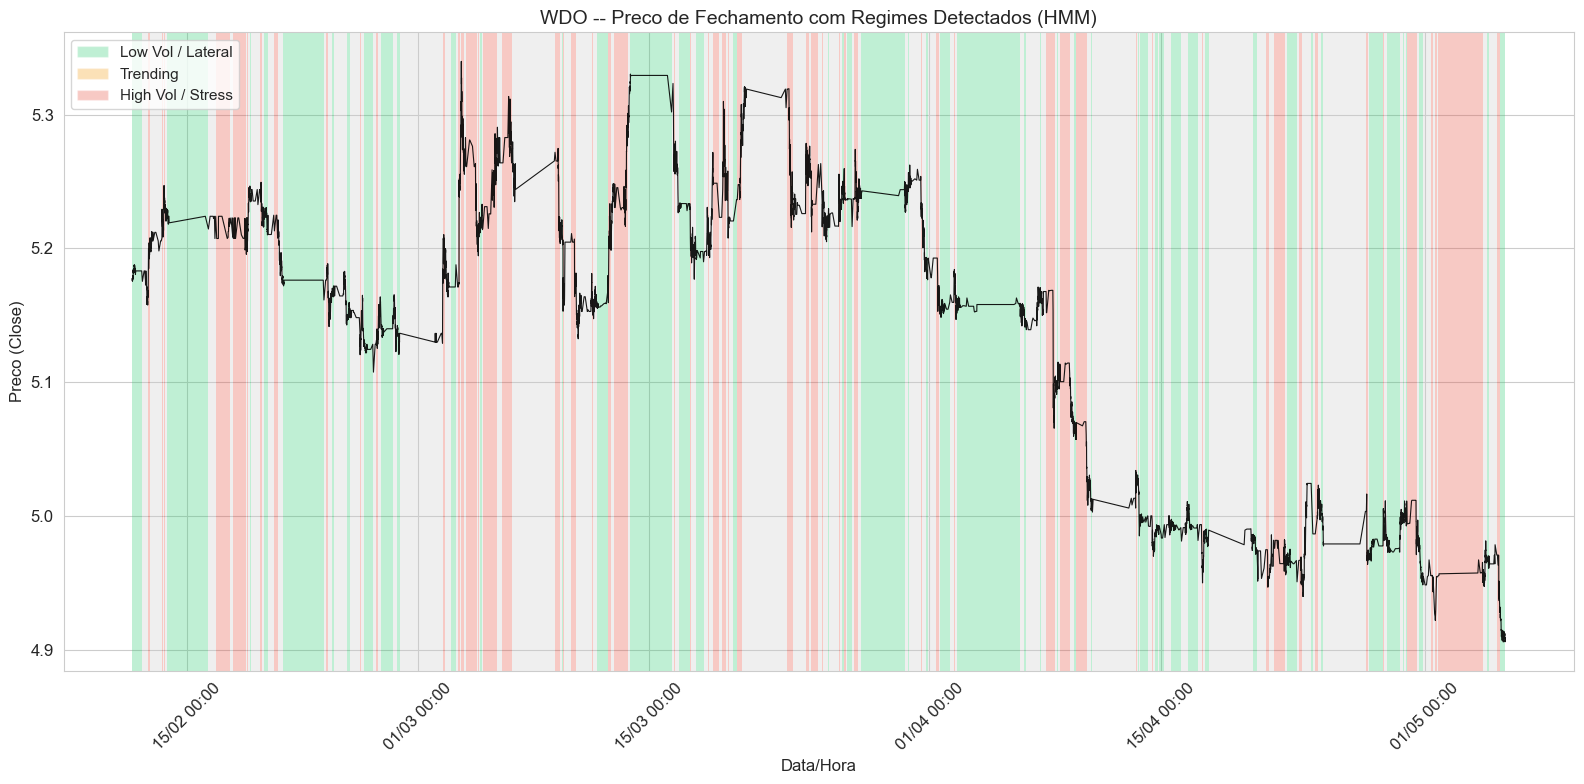

2026-05-05 19:31:56.410 | DEBUG    | src.models.hmm_regime:label_regimes:397 - Regime labels: {1: 'low_vol', 0: 'trending_1', 3: 'trending_2', 2: 'high_vol'}


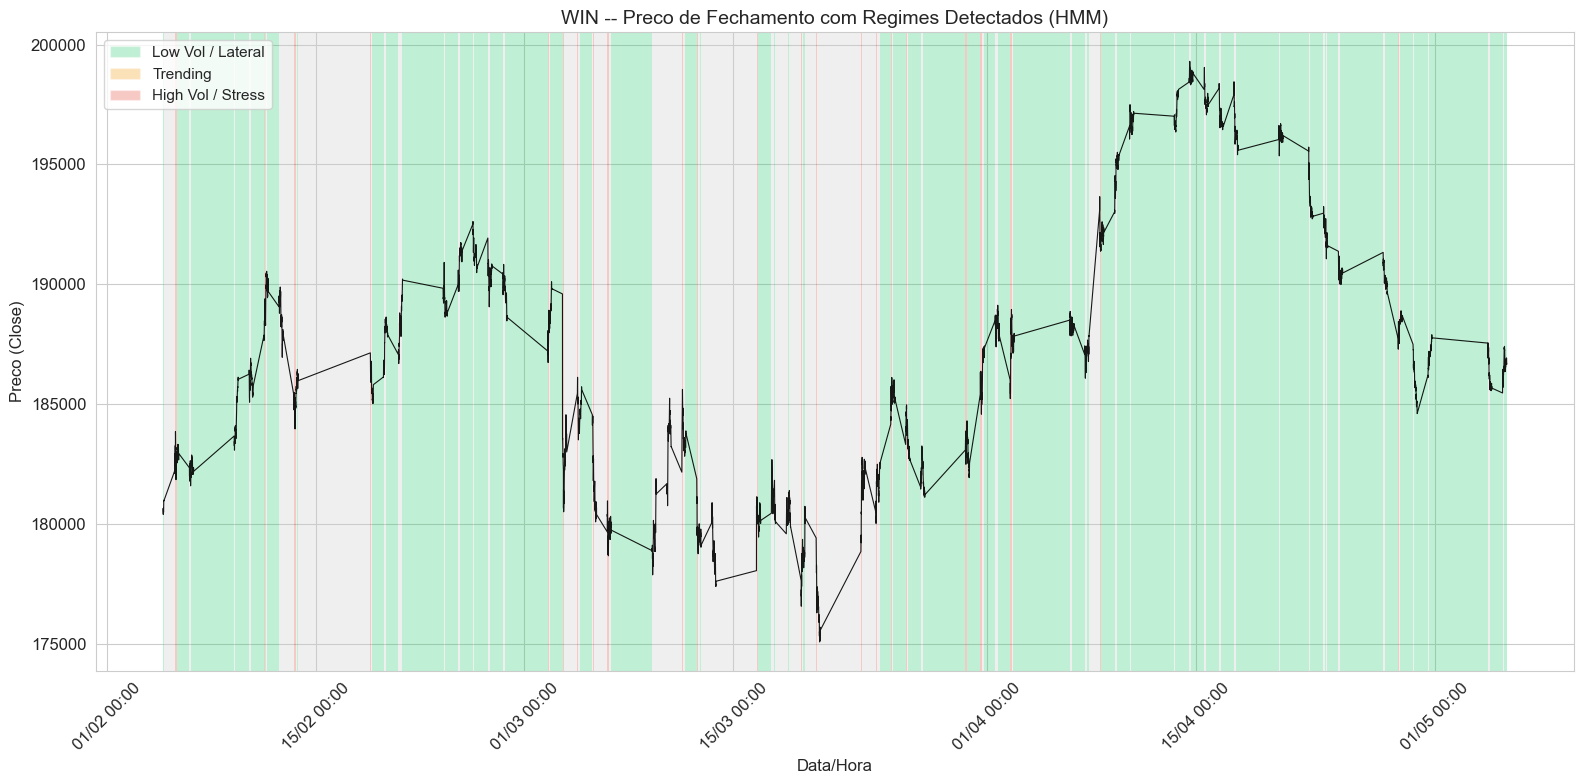

In [7]:
for symbol in regime_data:
    rd = regime_data[symbol]
    model = best_models[symbol]
    labels = model.label_regimes()
    
    # Alinhar precos com features
    prices = datasets[symbol].loc[rd.index, 'close']
    
    fig, ax = plt.subplots(figsize=(16, 8))
    
    # Colorir fundo pelos regimes
    for i in range(len(rd) - 1):
        regime_name = rd['regime_name'].iloc[i]
        color = REGIME_COLORS.get(regime_name, '#cccccc')
        ax.axvspan(
            rd.index[i], rd.index[i + 1],
            alpha=0.3, color=color, linewidth=0,
        )
    
    # Plotar preco
    ax.plot(prices.index, prices.values, color='black', linewidth=0.8, alpha=0.9)
    
    # Legenda customizada
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=REGIME_COLORS['low_vol'], alpha=0.3, label='Low Vol / Lateral'),
        Patch(facecolor=REGIME_COLORS['trending'], alpha=0.3, label='Trending'),
        Patch(facecolor=REGIME_COLORS['high_vol'], alpha=0.3, label='High Vol / Stress'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=11)
    
    ax.set_title(f'{symbol} -- Preco de Fechamento com Regimes Detectados (HMM)', fontsize=14)
    ax.set_xlabel('Data/Hora')
    ax.set_ylabel('Preco (Close)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:%M'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### 6.2 Distribuicao de Features por Regime

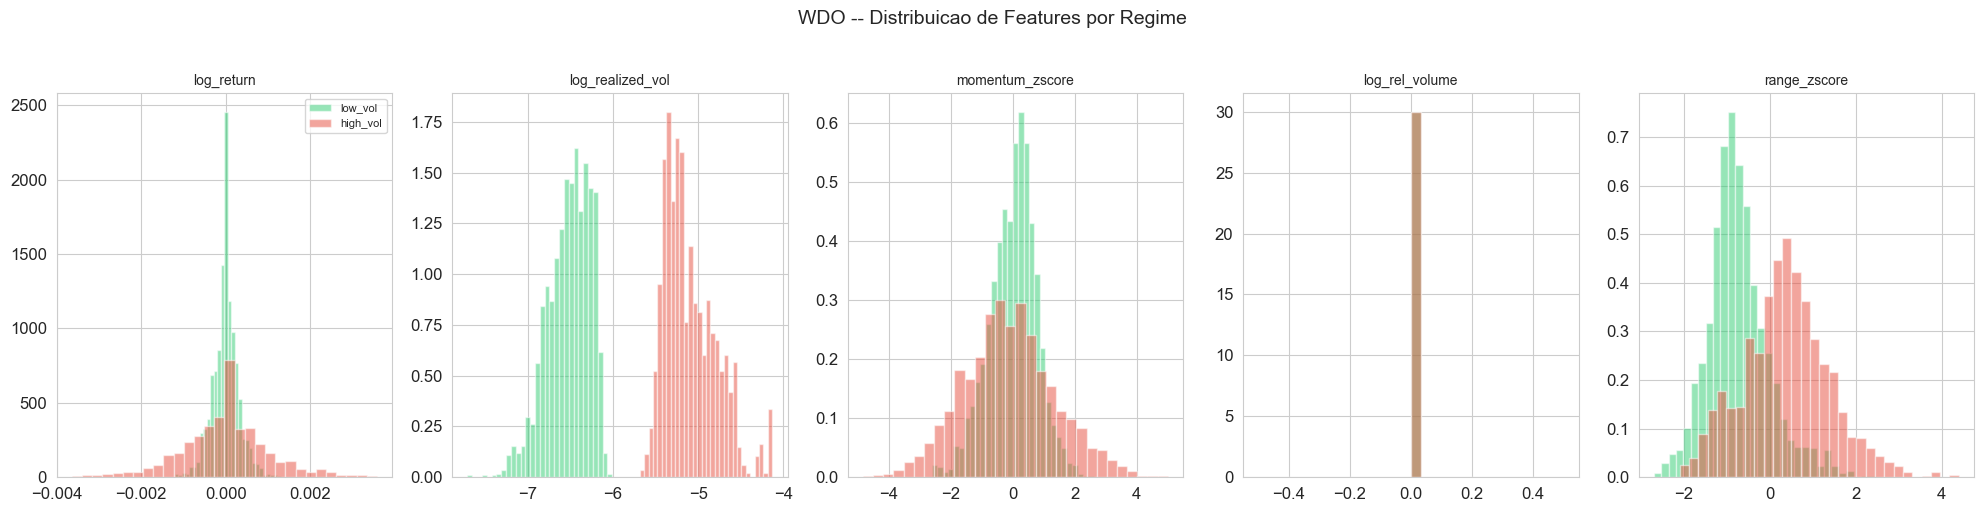

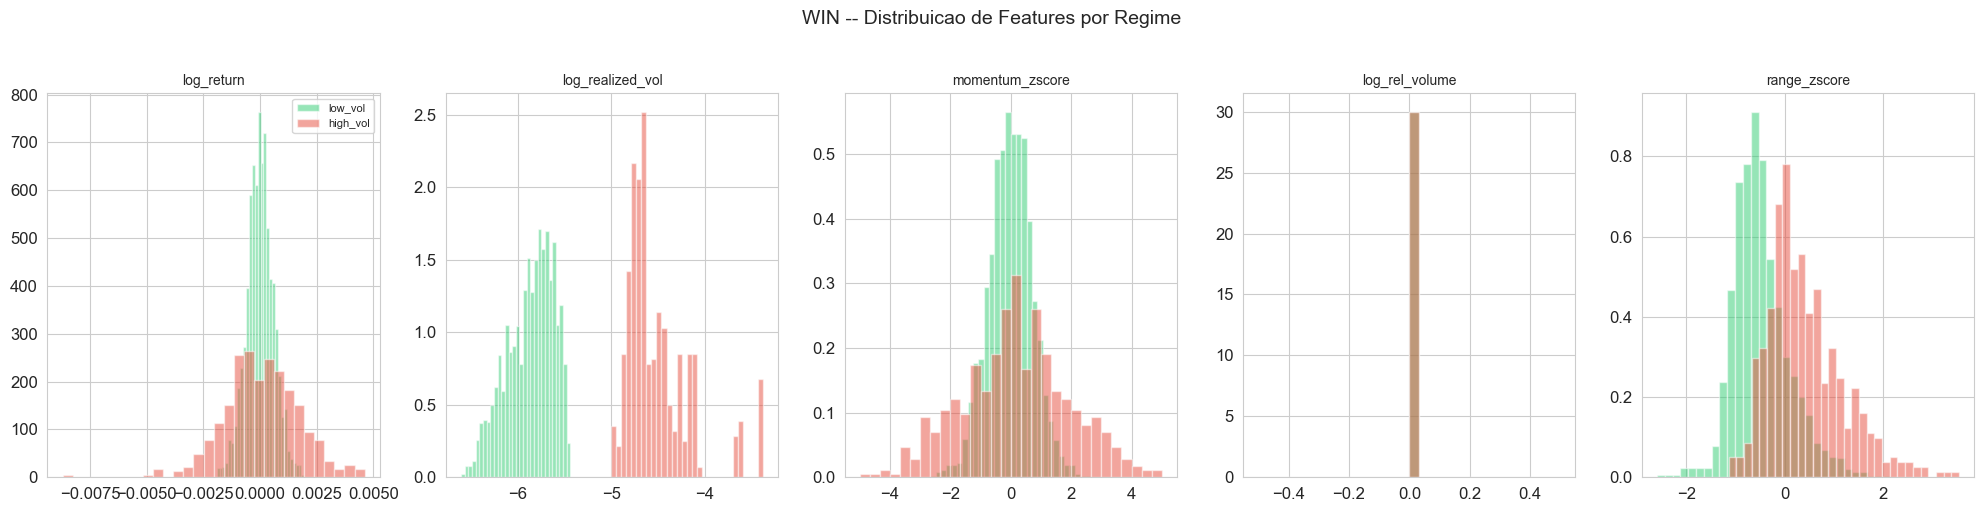

In [8]:
for symbol in regime_data:
    rd = regime_data[symbol]
    
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    fig.suptitle(f'{symbol} -- Distribuicao de Features por Regime', fontsize=14, y=1.02)
    
    for idx, col in enumerate(FEATURE_COLUMNS):
        ax = axes[idx]
        for regime_name in ['low_vol', 'trending', 'high_vol']:
            mask = rd['regime_name'] == regime_name
            if mask.sum() > 0:
                data = rd.loc[mask, col]
                ax.hist(
                    data, bins=30, alpha=0.5,
                    color=REGIME_COLORS[regime_name],
                    label=regime_name, density=True,
                )
        ax.set_title(col, fontsize=10)
        ax.set_xlabel('')
        if idx == 0:
            ax.legend(fontsize=8)
    
    plt.tight_layout()
    plt.show()

### 6.3 Matriz de Transicao

2026-05-05 19:32:02.922 | DEBUG    | src.models.hmm_regime:label_regimes:397 - Regime labels: {2: 'low_vol', 1: 'trending_1', 3: 'trending_2', 0: 'high_vol'}


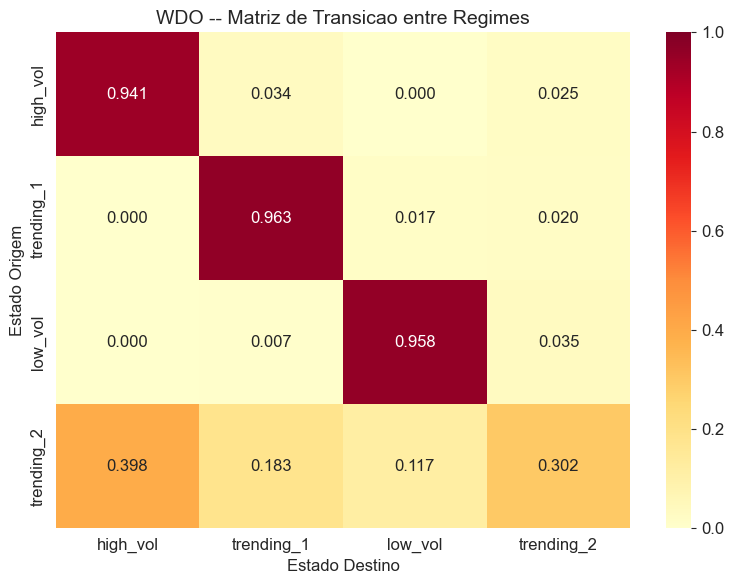

2026-05-05 19:32:03.076 | DEBUG    | src.models.hmm_regime:label_regimes:397 - Regime labels: {1: 'low_vol', 0: 'trending_1', 3: 'trending_2', 2: 'high_vol'}


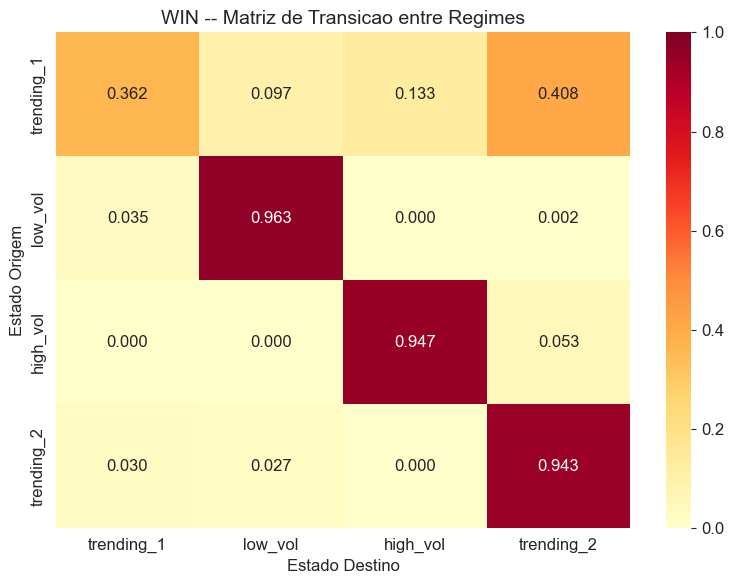

In [9]:
for symbol in regime_data:
    model = best_models[symbol]
    labels = model.label_regimes()
    
    transmat = model.model.transmat_
    state_names = [labels[i] for i in range(model.n_states)]
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        transmat,
        annot=True, fmt='.3f',
        xticklabels=state_names,
        yticklabels=state_names,
        cmap='YlOrRd',
        vmin=0, vmax=1,
        ax=ax,
    )
    ax.set_title(f'{symbol} -- Matriz de Transicao entre Regimes', fontsize=14)
    ax.set_xlabel('Estado Destino')
    ax.set_ylabel('Estado Origem')
    plt.tight_layout()
    plt.show()

### 6.4 Proporcao Temporal dos Regimes

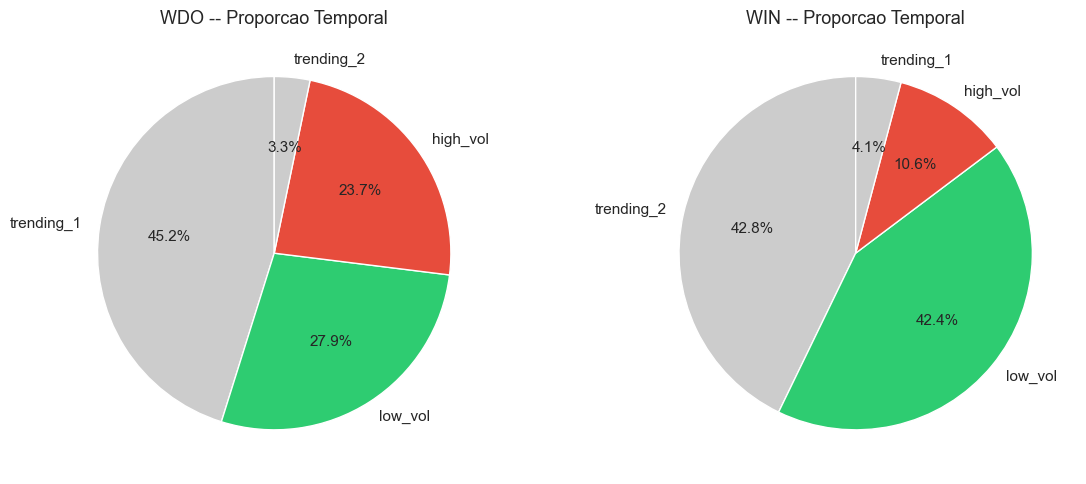

In [10]:
fig, axes = plt.subplots(1, len(regime_data), figsize=(12, 5))
if len(regime_data) == 1:
    axes = [axes]

for idx, (symbol, rd) in enumerate(regime_data.items()):
    ax = axes[idx]
    counts = rd['regime_name'].value_counts()
    
    colors = [REGIME_COLORS.get(name, '#cccccc') for name in counts.index]
    
    ax.pie(
        counts.values,
        labels=counts.index,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 11},
    )
    ax.set_title(f'{symbol} -- Proporcao Temporal', fontsize=13)

plt.tight_layout()
plt.show()

## 7. Exportacao dos Resultados

In [11]:
for symbol, rd in regime_data.items():
    output_path = PROCESSED_DIR / f'{symbol}_5m_regimes.parquet'
    rd.to_parquet(output_path, engine='pyarrow', index=True)
    print(f'Salvo: {output_path} ({len(rd)} rows)')

print('\nExportacao concluida.')

Salvo: C:\Users\marco\Documents\repositorios\quant-trading-system\data\processed\WDO_5m_regimes.parquet (7001 rows)
Salvo: C:\Users\marco\Documents\repositorios\quant-trading-system\data\processed\WIN_5m_regimes.parquet (4886 rows)

Exportacao concluida.


## 8. Resumo

In [12]:
print('=' * 60)
print('RESUMO DA ANALISE DE REGIMES')
print('=' * 60)

for symbol in regime_data:
    result = selection_results[symbol]
    rd = regime_data[symbol]
    model = best_models[symbol]
    stats = model.get_regime_statistics()
    
    states = rd['regime_id'].values
    transitions = (states[1:] != states[:-1]).sum()
    n_days = len(set(rd.index.date)) if hasattr(rd.index, 'date') else 1
    
    print(f'\n--- {symbol} ---')
    print(f'  Modelo: K={result.best_n_states}, cov={result.best_cov_type}')
    print(f'  BIC: {result.best_bic:.2f}')
    print(f'  Observacoes: {len(rd)}')
    print(f'  Dias de trading: {n_days}')
    print(f'  Transicoes/dia: {transitions / max(n_days, 1):.1f}')
    print(f'  Regimes:')
    for s in stats:
        prop = (states == s.state_id).mean()
        print(f'    {s.label}: duracao media={s.expected_duration:.1f} candles, proporcao={prop:.1%}')

print('\n' + '=' * 60)
print('Analise concluida com sucesso.')
print('=' * 60)

2026-05-05 19:32:03.390 | DEBUG    | src.models.hmm_regime:label_regimes:397 - Regime labels: {2: 'low_vol', 1: 'trending_1', 3: 'trending_2', 0: 'high_vol'}


2026-05-05 19:32:03.393 | DEBUG    | src.models.hmm_regime:label_regimes:397 - Regime labels: {1: 'low_vol', 0: 'trending_1', 3: 'trending_2', 2: 'high_vol'}


RESUMO DA ANALISE DE REGIMES

--- WDO ---
  Modelo: K=4, cov=full
  BIC: -115217.71
  Observacoes: 7001
  Dias de trading: 60
  Transicoes/dia: 7.4
  Regimes:
    high_vol: duracao media=16.9 candles, proporcao=23.7%
    trending_1: duracao media=27.3 candles, proporcao=45.2%
    low_vol: duracao media=23.8 candles, proporcao=27.9%
    trending_2: duracao media=1.4 candles, proporcao=3.3%

--- WIN ---
  Modelo: K=4, cov=full
  BIC: -77966.11
  Observacoes: 4886
  Dias de trading: 60
  Transicoes/dia: 5.6
  Regimes:
    trending_1: duracao media=1.6 candles, proporcao=4.1%
    low_vol: duracao media=27.3 candles, proporcao=42.4%
    high_vol: duracao media=18.8 candles, proporcao=10.6%
    trending_2: duracao media=17.5 candles, proporcao=42.8%

Analise concluida com sucesso.
